In [26]:
import numpy as np
import sympy as sym
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
import matplotlib.animation as animation
from IPython.display import HTML

The time independent Schrodinger equation is given by 

$$ \hat{H}\psi(x) = E\psi(x) $$

$$ -\frac{\hbar^2}{2m} \psi(x)'' + \hat{V}(x)\psi(x) = E\psi(x) $$

Which for infinite well potential $ \hat{V}(x) = 0 $ for $ -L < x < L $ and 0 elsewhere. Note that we have boundary conditions $ \psi(0) = \psi(L) = 0 $ for the infinite potential

Using finite central difference $ u_i'' = \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2} $ we discretise the equation inside the well, and have $ \psi = 0 $ outside of the well 

$$ \frac{-\hbar^2}{2m}(\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2}) = -E\psi_i $$

$$ \therefore -(\frac{\hbar}{2m \Delta x^2})\psi_{i+1} + (\frac{\hbar^2}{m \Delta x^2})\psi_{i} - (\frac{\hbar}{2m \Delta x^2})\psi_{i-1} = -E\psi_i $$

To enforce proper boundary condiitons ...

In [27]:
# using theory to solve for eigenvalues (energies), eigenstates for infinite well
# set m = 1, and use hbar = 1 convention
N       = 1000 # number of grid points
L       = 10 # domain: [-L, +L]
x       = np.linspace(-L, L, N)
dx      = x[1] - x[0]

 
# diagonal:     d_i = 2/dx^2
# off-diagonal: c = -1/2(dx^2)
c = -1.0 / (2.0 * dx**2)
d =  1.0 / dx**2
 
# build H on interior points only (N-2), enforcing psi=0 at boundaries
H = (diags(np.full(N-2, d), 0) # main diagonal
   + diags(np.full(N-3, c), 1) # upper off-diagonal
   + diags(np.full(N-3, c), -1)) # lower off-diagonal

In [37]:
evalues, eigenfunctions = eigsh(H, k=5, which='SM')
idx = np.argsort(evalues)
evalues = evalues[idx]
eigenfunctions = eigenfunctions[:, idx]

In [38]:
# normalising eigenfunctions
for n in range(eigenfunctions.shape[1]):
    norm = np.sqrt(np.trapezoid(eigenfunctions[:, n]**2, x[1:-1]))
    eigenfunctions[:, n] /= norm

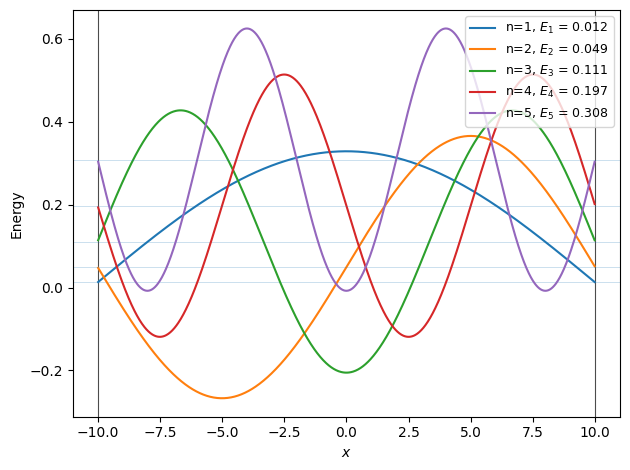

In [39]:
plt.axvline(-L, color='k', lw=0.8, alpha=0.7)
plt.axvline( L, color='k', lw=0.8, alpha=0.7)

for n in range(5):
    plt.plot(x[1:-1], eigenfunctions[:, n] + evalues[n], label=fr'n={n+1}, $E_{{{n+1}}}$ = {evalues[n]:.3f}')
    plt.axhline(evalues[n], lw=0.4, alpha=0.4)


plt.xlabel(r'$x$')
plt.ylabel('Energy')
plt.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()